In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from tqdm import tqdm
import os
import pickle

# =========================
# CONFIG
# =========================
CSV_PATH = "./dataset/final_processed_data.csv"  # your dataset
COL1 = "SMILES1"
COL2 = "SMILES2"

EMBED_DIM = 128    #MIGHT NEED TO CHANGE LATER
USE_GAT = True  # set False to use GCN
CACHE_PATH = "drug_embeddings.pkl"

device = torch.device("cpu")


# =========================
# STEP 1: RDKit → Graph
# =========================
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            atom.GetTotalNumHs()
        ])

    x = torch.tensor(atom_features, dtype=torch.float)

    # Edge index
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    if len(edge_index) == 0:
        return None

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    data = Data(x=x, edge_index=edge_index)
    return data


# =========================
# STEP 2: GNN Model
# =========================
class GNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        if USE_GAT:
            self.conv1 = GATConv(input_dim, hidden_dim)
            self.conv2 = GATConv(hidden_dim, hidden_dim)
        else:
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)

        self.relu = nn.ReLU()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.relu(self.conv1(x, edge_index))
        x = self.relu(self.conv2(x, edge_index))

        # single graph → batch index = zeros
        batch = torch.zeros(x.size(0), dtype=torch.long)

        x = global_mean_pool(x, batch)
        return x


# =========================
# STEP 3: Load dataset
# =========================
df = pd.read_csv(CSV_PATH)

# Collect unique SMILES
all_smiles = set(df[COL1]).union(set(df[COL2]))

print(f"Total unique drugs: {len(all_smiles)}")


# =========================
# STEP 4: Initialize model
# =========================
# We need a dummy graph to get input dimension
for sm in all_smiles:
    g = smiles_to_graph(sm)
    if g is not None:
        input_dim = g.x.shape[1]
        break

model = GNNEncoder(input_dim, EMBED_DIM).to(device)
model.eval()


# =========================
# STEP 5: Load cache if exists
# =========================
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        embedding_cache = pickle.load(f)
else:
    embedding_cache = {}


# =========================
# STEP 6: Compute embeddings
# =========================
for sm in tqdm(all_smiles):
    if sm in embedding_cache:
        continue

    graph = smiles_to_graph(sm)
    if graph is None:
        embedding_cache[sm] = np.zeros(EMBED_DIM)
        continue

    with torch.no_grad():
        emb = model(graph).cpu().numpy().flatten()

    embedding_cache[sm] = emb

# Save cache
with open(CACHE_PATH, "wb") as f:
    pickle.dump(embedding_cache, f)

print("Embeddings computed and cached.")


# =========================
# STEP 7: Create pair embeddings
# =========================
# Save per-drug embeddings
with open("drug_graph_embeddings.pkl", "wb") as f:
    pickle.dump(embedding_cache, f)

Total unique drugs: 644


100%|██████████| 644/644 [00:00<?, ?it/s]

Embeddings computed and cached.


In [9]:
all_vecs = np.array(list(emb.values()))

print("Mean:", np.mean(all_vecs))
print("Std:", np.std(all_vecs))

Mean: 0.2459072248416618
Std: 0.3226262184132898


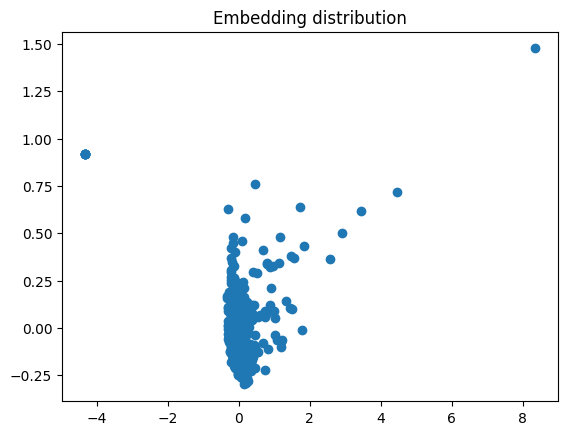

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = np.array(list(emb.values()))

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.scatter(X2[:, 0], X2[:, 1])
plt.title("Embedding distribution")
plt.show()